# CROCUS Data Access

This notebook demonstrates how to access sensor data from the CROCUS 
(Community Research on Climate and Urban Science) network of Waggle/Sage
nodes deployed across Chicagoland. Check current sensor availability and recent data through the Sage portal:

  - All nodes: https://portal.sagecontinuum.org/nodes
  - NEIU node:  https://portal.sagecontinuum.org/nodes/W08D

CROCUS data is also archived at:

  - https://data.ess-dive.lbl.gov/portals/crocus/Data


### Network Notes

- All CROCUS WXT and AQT nodes were offline approximately December 2025 &ndash; 
  March 2026 during a network-wide maintenance period.
- The 5-minute averaging plugin was deployed across all nodes when they came 
  back online in April 2026. Historical WXT data prior to this transition was 
  sampled at >1Hz; historical AQT data was at 1-minute intervals.
- All data returned by the query functions is resampled to 5-minute means for 
  consistency across years.


## Audience

This notebook is designed for students who are new to Python or early in
their data science journey. The `sage_utils.py` functions return data in
**wide format** &mdash; one column per variable, one row per timestamp &mdash; which
is familiar to anyone who has worked with a spreadsheet.

The native Sage Data Client returns data in **long format** &mdash; one row per
measurement &mdash; which is more flexible for certain analyses but requires
additional wrangling steps. Experienced Python users who prefer the native
format should refer to:
  - https://sagecontinuum.org/docs/tutorials/
  - https://github.com/sagecontinuum/sage-data-client
  - https://crocus-urban.github.io/instrument-cookbooks/

The source code in `sage_utils.py` and `crocus_sites.py` is documented
and readable &mdash; students are encouraged to look at how the functions work
and adapt them for their own projects.

### CROCUSSite Class

The `CROCUSSite` class in `crocus_sites.py` contains metadata for each CROCUS 
field site including full name, Waggle/Virtual Sage Node ID (vsn), 
site abbreviation, geographic coordinates, and sensor availability flags.
Each site is a `CROCUSSite` instance accessible directly by name (e.g. `NEIU`, `CSU`).
This allows users to pass a site's memorable abbreviation (e.g. *NEIU*) 
to the query functions, rather than the VSN ID (e.g. *W08D*).

### sage_utils

The querying functions below are found in the local package sage_utils. These
functions return wide-format DataFrames for each device with intuitive column names, missing values replaced with NaN.  WXT and AQT data resampled to a consistent 5-minute resolution regardless of the underlying sampling rate.

 - `query_aqt(site,start,end)`  returns a wide air quality data frame

 - `query_wxt(site,start,end)`  returns a wide weather data frame
 
 - `query_raingauge(site,start,end)` returns a wide RG-15 rain gauge data frame

 - `query_sapflow(site,start,end)` returns dictionary of sapflow data frames

 - `query_mfr(site,start,end)`     returns a dictionary of MFR soil data


In [78]:
# Standard library
import datetime as dt
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import (
    query_aqt, query_wxt,
    query_sapflow, query_mfr,
    query_raingauge, last_n_hours
)

ssl._create_default_https_context = ssl._create_unverified_context

### Site list

The code block below lists available sites, their abbreviations and VSN IDs.

In [79]:
for site in ALL_SITES:
    print(f"{site.abbr:<8} {site.vsn}  {site.full_name}")

ATMOS    W0A4  Argonne Testbed for Multiscale Observational Science
BIG      W0A0  Blacks in Green (West Woodlawn)
CCICS    W08B  Carruthers Center for Inner City Studies — Bronzeville (NEIU satellite)
CSU      W08E  Chicago State University
HUM      W0A1  Humboldt Park
NEIU     W08D  Northeastern Illinois University
NU       W099  Northwestern University
SHEDD    W09E  Shedd Aquarium
UIC      W096  University of Illinois Chicago


In [ ]:
# Set a SITE for use throughout the rest of this notebook.
SITE = NEIU  # change this to CSU, UIC, NEIU, NU, BIG, etc. to query a different site
print(f"Querying: {SITE.full_name} ({SITE.vsn})")

Querying: Humboldt Park (W0A1)


To see documentation for any function, type the function name followed by ?
An example is provided in the block below.

In [81]:
query_aqt?

Signature: query_aqt(site, start, end=None, resample='5min')
Docstring:
Query Vaisala AQT530 air quality transmitter data from the Sage/Waggle API.
Returns PM1, PM2.5, PM10, CO, NO, NO2, O3, temperature, humidity and
pressure resampled to a consistent 5-minute resolution.
NB: Some nodes have PM sensors that have stopped functioning — check
site status before interpreting PM data.

Parameters
----------
site: CROCUSSite
     Site object from crocus_sites.py, e.g. NEIU
start : str
    Start datetime, absolute e.g. '2023-06-01' or relative e.g. '-1h'
end : str, optional
    End datetime. If omitted, defaults to now.
resample : str, optional
    Pandas offset string for output resolution, e.g. '1min', '5min', '1h'.
    Default is RESAMPLE_INTERVAL. Should be >= native data resolution.    

Returns
-------
pd.DataFrame resampled to `resample` interval with UTC DatetimeIndex
and columns:
    humidity, pressure, temp, co, no, no2, o3, pm1, pm10, pm25, vsn, sensor
File:      ~/py/crocus/sage_u

## WXT (Weather Transmitter)

Temperature, humidity, pressure, rain accumulation, wind direction, wind speed.

### Recent Data (Last N hours)

In [82]:
start, end = last_n_hours(1)  # return(N) a (start,end) tuple for last N hours
PLOT_WXT = False

if not SITE.has_wxt:
    print(f"{SITE.abbr} has no WXT configured.")
else:
    wxt_last_hour = query_wxt(SITE, start, end)
    PLOT_WXT = not wxt_last_hour.empty
    print(wxt_last_hour.columns)
    if wxt_last_hour.empty:
        print(f"No WXT data returned for {SITE.abbr}.")
    else:
        wxt_last_hour.head()

Index(['humidity', 'pressure', 'temp', 'rain', 'wind_dir', 'wind_speed', 'vsn',
       'sensor'],
      dtype='str')


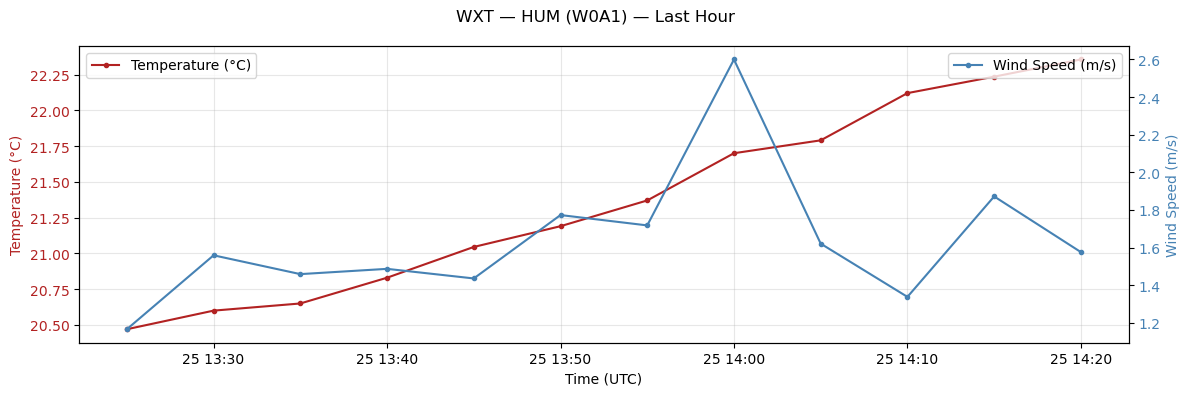

In [83]:
if PLOT_WXT:

    fig, ax1 = plt.subplots(figsize=(12, 4))

    ax1.plot(
        wxt_last_hour.index,
        wxt_last_hour["temp"],
        marker="o",
        markersize=3,
        color="firebrick",
        label="Temperature (°C)",
    )
    ax1.set_ylabel("Temperature (°C)", color="firebrick")
    ax1.tick_params(axis="y", labelcolor="firebrick")
    ax1.set_xlabel("Time (UTC)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        wxt_last_hour.index,
        wxt_last_hour["wind_speed"],
        marker="o",
        markersize=3,
        color="steelblue",
        label="Wind Speed (m/s)",
        )
    ax2.set_ylabel("Wind Speed (m/s)", color="steelblue")
    ax2.tick_params(axis="y", labelcolor="steelblue")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    fig.suptitle(f"WXT — {SITE.abbr} ({SITE.vsn}) — Last Hour", fontsize=12)
    fig.tight_layout()
    plt.show()

## AQT (Air Quality Transmitter)

PM<sub>10</sub>, PM<sub>2.5</sub>, PM<sub>1</sub>, 
CO, NO, NO<sub>2</sub>, O<sub>3</sub>, temperature, humidity and pressure.
Several nodes have PM sensors which stopped functioning. This cell prints the column names of the available data.

In [84]:
start, end = last_n_hours(1)
PLOT_AQT = False

if not SITE.has_aqt:
    print(f"{SITE.abbr} has no AQT configured.")
else:
    aqt_last_hour = query_aqt(SITE, start, end)
    PLOT_AQT = not aqt_last_hour.empty
    print(aqt_last_hour.columns)
    if aqt_last_hour.empty:
        print(f"No AQT data returned for {SITE.abbr}.")
    else:
        aqt_last_hour.head()

Index(['humidity', 'pressure', 'temp', 'co', 'no', 'no2', 'o3', 'pm1', 'pm10',
       'pm25', 'vsn', 'sensor'],
      dtype='str')


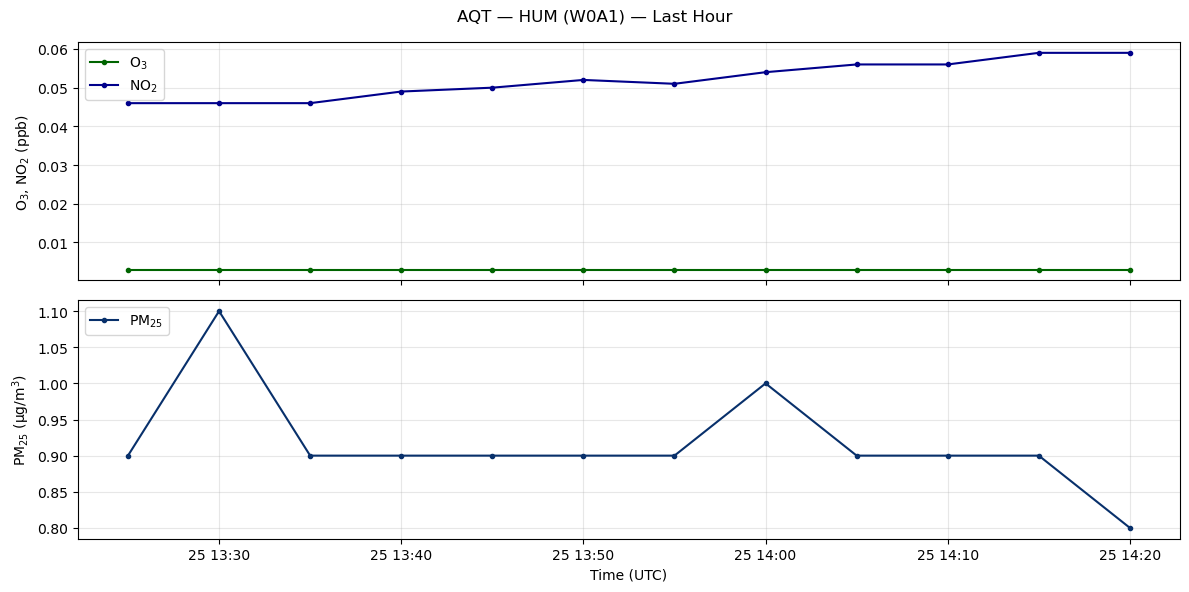

In [85]:
if PLOT_AQT:

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(aqt_last_hour.index, aqt_last_hour['o3'],
         marker='o', markersize=3, label='O$_3$', color='darkgreen')
    ax1.plot(aqt_last_hour.index, aqt_last_hour['no2'],
         marker='o', markersize=3, label='NO$_2$', color='darkblue')
    ax1.set_ylabel('O$_3$, NO$_2$ (ppb)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2.plot(aqt_last_hour.index, aqt_last_hour['pm25'],
         marker='o', markersize=3, label='PM$_{25}$', color='#08306b')
    ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
    ax2.set_xlabel('Time (UTC)')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — Last Hour', fontsize=12)
    fig.tight_layout()
    plt.show()

## Data with Specified Date Range

In [86]:
# This can take 1.5s to run
START = "2026-05-01"  # start is at the beginning of this day
END   = "2026-05-10"  # end is at the beginning of this day

df_aqt = query_aqt(SITE,START,END)

WXT queries can take  ~6-8 minutes/day for 2023 data due to >1Hz historical sampling rate.

In [87]:
df_wxt = query_wxt(SITE,START,END)

In [88]:
if not df_wxt.empty:
    print(f"df_aqt: {df_aqt.shape}, {df_aqt.memory_usage(deep=True).sum() / 1e6:.2f} MB")
    print(f"df_wxt: {df_wxt.shape}, {df_wxt.memory_usage(deep=True).sum() / 1e6:.2f} MB")

df_aqt: (2592, 12), 0.53 MB
df_wxt: (2592, 8), 0.45 MB


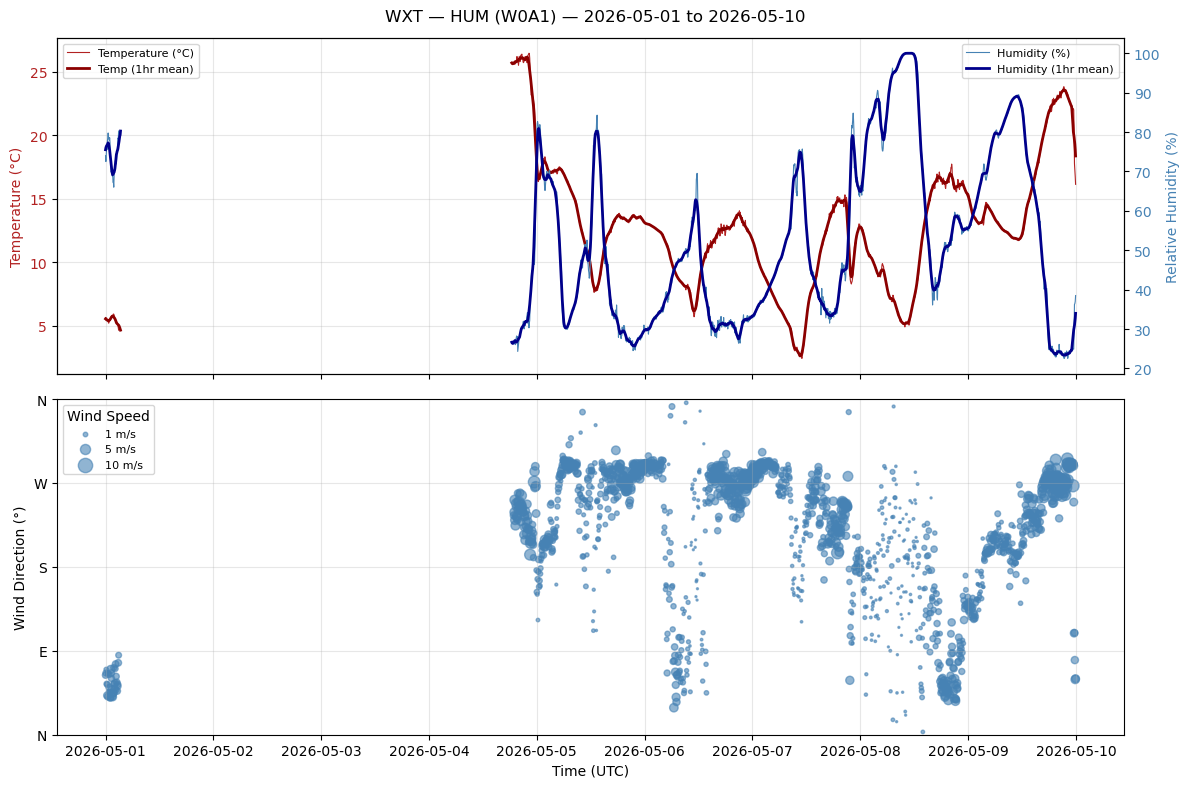

In [89]:
if not df_wxt.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Panel 1: Temperature and Humidity ---
    ax1.plot(df_wxt.index, df_wxt['temp'],
             color='firebrick', linewidth=0.8, label='Temperature (°C)')
    ax1.plot(df_wxt.index,
             df_wxt['temp'].rolling('60min', center=True).mean(),
             color='darkred', linewidth=2, label='Temp (1hr mean)')
    ax1.set_ylabel('Temperature (°C)', color='firebrick')
    ax1.tick_params(axis='y', labelcolor='firebrick')
    ax1.grid(True, alpha=0.3)

    ax1b = ax1.twinx()
    ax1b.plot(df_wxt.index, df_wxt['humidity'],
          color='steelblue', linewidth=0.8, label='Humidity (%)')
    ax1b.plot(df_wxt.index,
              df_wxt['humidity'].rolling('60min', center=True).mean(),
              color='darkblue', linewidth=2, label='Humidity (1hr mean)')
    ax1b.set_ylabel('Relative Humidity (%)', color='steelblue')
    ax1b.tick_params(axis='y', labelcolor='steelblue')

    ax1.legend(loc='upper left', fontsize=8)
    ax1b.legend(loc='upper right', fontsize=8)

    # --- Panel 2: Wind direction, dot size proportional to wind speed ---
    # Normalize wind speed for marker size — scale to reasonable dot range
    speed        = df_wxt['wind_speed'].fillna(0)
    marker_sizes = (speed / speed.max() * 80).clip(lower=2)

    ax2.scatter(df_wxt.index, df_wxt['wind_dir'],
                s=marker_sizes,
                color='steelblue', alpha=0.6)
    ax2.set_ylabel('Wind Direction (°)')
    ax2.set_ylim(0, 360)
    ax2.set_yticks([0, 90, 180, 270, 360])
    ax2.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
    ax2.set_xlabel('Time (UTC)')
    ax2.grid(True, alpha=0.3)

    # Add a size legend for wind speed
    for speed_val, label in [(1, '1 m/s'), (5, '5 m/s'), (10, '10 m/s')]:
        size = speed_val / df_wxt['wind_speed'].max() * 80
        ax2.scatter([], [], s=max(size, 2), color='steelblue',
                alpha=0.6, label=label)
    ax2.legend(loc='upper left', fontsize=8, title='Wind Speed')

    fig.suptitle(f'WXT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

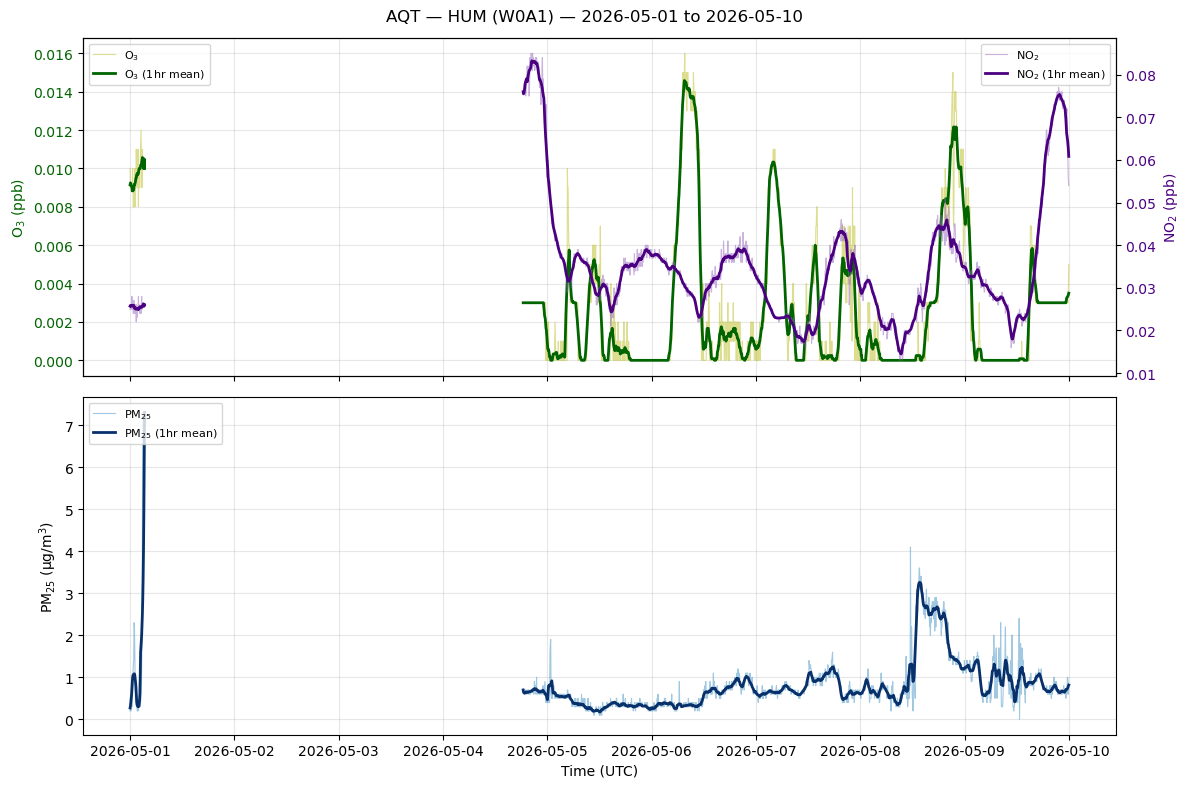

In [90]:
if not df_aqt.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Panel 1: O3 and NO2 ---
    ax1.plot(df_aqt.index, df_aqt['o3'],
            color='tab:olive', linewidth=0.8, alpha=0.5, label='O$_3$')
    ax1.plot(df_aqt.index,
            df_aqt['o3'].rolling('60min', center=True).mean(),
           color='darkgreen', linewidth=2, label='O$_3$ (1hr mean)')
    ax1.set_ylabel('O$_3$ (ppb)', color='darkgreen')
    ax1.tick_params(axis='y', labelcolor='darkgreen')
    ax1.grid(True, alpha=0.3)

    ax1b = ax1.twinx()
    ax1b.plot(df_aqt.index, df_aqt['no2'],
              color='tab:purple', linewidth=0.8, alpha=0.5, label='NO$_2$')
    ax1b.plot(df_aqt.index,
              df_aqt['no2'].rolling('60min', center=True).mean(),
              color='indigo', linewidth=2, label='NO$_2$ (1hr mean)')
    ax1b.set_ylabel('NO$_2$ (ppb)', color='indigo')
    ax1b.tick_params(axis='y', labelcolor='indigo')

    ax1.legend(loc='upper left', fontsize=8)
    ax1b.legend(loc='upper right', fontsize=8)

    # --- Panel 2: PM2.5 ---
    ax2.plot(df_aqt.index, df_aqt['pm25'],
             color='#4393c3', linewidth=0.8, alpha=0.5, label='PM$_{25}$')
    ax2.plot(df_aqt.index,
             df_aqt['pm25'].rolling('60min', center=True).mean(),
            color='#08306b', linewidth=2, label='PM$_{25}$ (1hr mean)')
    ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
    ax2.set_xlabel('Time (UTC)')
    ax2.legend(loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

## Sap Flow Meters

These devices communicate to the site Waggle node with a LoRaWAN (Long Range Wide Area Network).

In [91]:
start, end = last_n_hours(24)
PLOT_SAPFLOW = False
sapflow = None

if not SITE.has_sapflow:
    print(f"{SITE.abbr} has no sap flow sensors — skipping.")
    PLOT_SAPFLOW = False
else:
    sapflow = query_sapflow(SITE, start, end)
    PLOT_SAPFLOW = bool(sapflow)
    if not PLOT_SAPFLOW:
        print(f"No sap flow data returned for {SITE.abbr}.")
    else:
        print("Trees with data:", list(sapflow.keys()))

HUM has no sap flow sensors — skipping.


In [92]:
if PLOT_SAPFLOW:
    # Show which trees returned data
    print("Trees with data:", list(sapflow.keys()))

    # Inspect one tree
    if sapflow:
        first = list(sapflow.keys())[0]
        print(f"\n{first}:")
        print(sapflow[first].head())
        print(sapflow[first].dtypes)

In [93]:
if sapflow:
    fig, ax = plt.subplots(figsize=(12, 4))

    for label, df in sapflow.items():
        ax.plot(df.index, df['inner'],
                marker='o', markersize=2, label=f'{label} inner')
        ax.plot(df.index, df['outer'],
                marker='o', markersize=2, linestyle='--', label=f'{label} outer')

    ax.set_ylabel('Uncorrected Sap Flow (cm/hr)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.suptitle(f'Sap Flow — {SITE.abbr} ({SITE.vsn}) — Last 24 Hours', fontsize=12)
    fig.tight_layout()
    plt.savefig(f'figures/{SITE.abbr}_sapflow.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No sap flow data available.")

No sap flow data available.


In [94]:
# A short inspection of reporting and battery voltage range
if sapflow:
    for label, df in sapflow.items():
        print(f"{label}: {len(df)} rows, "
            f"{df['inner'].isna().sum()} NaN inner, "
            f"battery range {df['battery_voltage'].min():.2f}–{df['battery_voltage'].max():.2f}V")

## Multi-Function Research (MFR) Soil Data

Air temperature, pressure, relative humidity, water conductivity, water depth, water temperature, heat flux, soil temperature, ... and moisture at multiple depths. This device communicates to the site Waggle node with a LoRaWAN (Long Range Wide Area Network).

In [95]:
#start, end = last_n_hours(24)   # Last 24 hours
START = '2026-03-01'
END   = '2026-05-20'
mfr = None
PLOT_MFR = False

if not SITE.has_mfr:
    print(f"{SITE.abbr} has no MFR nodes — skipping.")
    PLOT_MFR = False
else:
    mfr = query_mfr(SITE, START, END)
    PLOT_MFR = bool(mfr)
    # Print MFR sub-site serial numbers and labels for this site
    print(SITE.mfr)
    if not PLOT_MFR:
        print(f"No MFR data returned for {SITE.abbr}.")

HUM has no MFR nodes — skipping.


In [96]:
if mfr:
    # Compute common y-axis limits across all sites
    temp_min = min(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].min().min() 
                   for df in mfr.values())
    temp_max = max(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].max().max() 
                   for df in mfr.values())
    vwc_min  = min(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].min().min() 
                   for df in mfr.values())
    vwc_max  = max(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].max().max() 
                   for df in mfr.values())

    # Add a small margin
    temp_pad = (temp_max - temp_min) * 0.05
    vwc_pad  = (vwc_max  - vwc_min)  * 0.05

    for label, df in mfr.items():
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        for col, depth in [('temp_15cm', '15 cm'), ('temp_30cm', '30 cm'),
                            ('temp_45cm', '45 cm'), ('temp_60cm', '60 cm')]:
            if col in df.columns:
                ax1.plot(df.index, df[col], linestyle='none', marker='o',
                         label=depth, markersize=2)
        ax1.set_ylim(temp_min - temp_pad, temp_max + temp_pad)
        ax1.set_ylabel('Soil Temperature (°C)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        for col, depth in [('vwc_15cm', '15 cm'), ('vwc_30cm', '30 cm'),
                            ('vwc_45cm', '45 cm'), ('vwc_60cm', '60 cm')]:
            if col in df.columns:
                ax2.plot(df.index, df[col],
                         linestyle='none', marker='o', markersize=2,
                         label=depth)
        ax2.set_ylim(vwc_min - vwc_pad, vwc_max + vwc_pad)
        ax2.set_ylabel('Volumetric Water Content (%)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'MFR {label} — {SITE.abbr} ({SITE.vsn}) — {df.index.min().date()} to {df.index.max().date()}',
                     fontsize=12)
        # Add serial number as small annotation
        serial = next(k for k, v in SITE.mfr.items() if v['label'] == label)
        fig.text(0.99, 0.98, f'Serial: {serial}',
            ha='right', va='top',
            fontsize=7, color='0.5',
            transform=fig.transFigure)
        
        fig.tight_layout()
        plt.savefig(f'figures/{SITE.abbr}_mfr_{label}_soil.png', dpi=150, bbox_inches='tight')
        plt.show()

NB The savannah soil texture at NEIU is mostly clay which may be responsible for saturation and the narrow range of VWC.

In [97]:
# Simple soil statistics

if mfr:
    for label, df in mfr.items():
        print(f"\n{label}:")
        print(f"  Shape: {df.shape}")
        print(f"  Date range: {df.index.min()} to {df.index.max()}")
        print(f"\n  Column statistics:")
        cols = ['temp_15cm', 'temp_30cm', 'temp_45cm', 'temp_60cm',
                'vwc_15cm',  'vwc_30cm',  'vwc_45cm',  'vwc_60cm']
        for col in cols:
            if col in df.columns:
                valid = df[col].dropna()
                print(f"  {col:12}: n={len(valid):4d}  "
                      f"min={valid.min():7.2f}  "
                      f"max={valid.max():7.2f}  "
                      f"mean={valid.mean():7.2f}")

## Optical Rain Sensor: Hydreon RG-15

In [98]:
if SITE.has_raingauge:
    start, end = last_n_hours(24 * 30)  # last 30 days
    rain = query_raingauge(SITE, start, end)

    if rain.empty:
        print(f"No rain events recorded at {SITE.abbr} in the last 30 days.")
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        # Rain rate
        ax1.plot(rain.index, rain['rint'],
                 color='steelblue', linewidth=0.8, label='Rain rate (mm/hr)')
        ax1.set_ylabel('Rain Rate (mm/hr)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.set_ylim(bottom=0)
        ax1.grid(True, alpha=0.3)

        # Event accumulation
        ax2.plot(rain.index, rain['event_acc'],
                 color='#08306b', linewidth=0.8, label='Event accumulation (mm)')
        ax2.set_ylabel('Event Accumulation (mm)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.set_ylim(bottom=0)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'RG-15 Rain Gauge — {SITE.abbr} ({SITE.vsn})', fontsize=12)
        fig.tight_layout()
        plt.savefig(f'figures/{SITE.abbr}_rain.png', dpi=150, bbox_inches='tight')
        plt.show()
      
else:
    print(f"{SITE.abbr} has no rain gauge configured.")

No rain events recorded at HUM in the last 30 days.
